list all steps involved in creating all datasets for the experiment

## Create training data pool from IslandViewer4 database 
- source: https://www.pathogenomics.sfu.ca/islandviewer/download/
- accession to taxonomic id: https://ftp.ncbi.nlm.nih.gov/pub/taxonomy/accession2taxid/ 
- IslandViewer4 data contains only accession id and the positions of genomic islands found in each accession
- use the information from accession2taxid to assign the taxonomic info to each accession

In [10]:
# import libraries
import gzip
import taxoniq
import pandas as pd 
import sqlite3
import gzip
from pandarallel import pandarallel
import altair as alt
from tqdm import tqdm 
import os
import pickle
from utils.util import sample_n_strains_per_species, sample_n_subtaxa_per_taxa

# Initialize pandarallel
pandarallel.initialize(progress_bar=True)
alt.data_transformers.disable_max_rows()

FOLDER_TRAIN_DATA = "./dataset/train_folder"
FOLDER_TEST_DATA = "./dataset/test_folder"
FOLDER_TO_ISLANDVIEWER_DATA = "./dataset/prev_studies/islandviewer/"
FOLDER_TO_TRAIN_DATA_INFO = "./dataset/train_folder/info"

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [2]:
islandviewer_gis = pd.read_csv(f"{FOLDER_TO_ISLANDVIEWER_DATA}/all_gis_islandviewer_iv4.csv")
islandviewer_gis_stats = islandviewer_gis.groupby('accession').size().reset_index(name='n_samples').sort_values(by='n_samples', ascending=False)

## Get taxonomic information of the accessions in IslandViewer4 database

### Create SQLite database
- insert the accession2taxid data into a table named accession2taxid with the following variables: accession, accession_version, taxid, and gi

In [ ]:
## required file: "nucl_gb.accession2taxid.gz"
## output: SQLite database named "accessionTaxa.sqlite"

# conn = sqlite3.connect("accessionTaxa.sqlite")
# cur = conn.cursor()

# cur.execute("CREATE TABLE IF NOT EXISTS accession2taxid (accession VARCHAR, accession_version VARCHAR, taxid INTEGER, gi INTEGER)")
# conn.commit()

# with gzip.open("nucl_gb.accession2taxid.gz", "rt") as f:
#     for line in f:
#         parts = line.strip().split('\t')
#         #print(parts)
#         cur.execute("INSERT INTO accession2taxid VALUES (?, ?, ?, ?)", (parts[0], parts[1], parts[2], int(parts[3]) if parts[3].isdigit() else None))


### Access the database and retrieve the taxid of the selected accessions

In [ ]:
## connect to the database "accessionTaxa.sqlite"

# conn = sqlite3.connect("accessionTaxa.sqlite")
# cur = conn.cursor()
# values = islandviewer_gis.accession.unique()  # or ['a', 'b', 'c'] for strings

# placeholders = ','.join('?' for _ in values)  # generates ?,?,?,? for param substitution
# query = f"SELECT * FROM accession2taxid WHERE accession_version IN ({placeholders})"

# cur.execute(query, values)
# results = cur.fetchall()

In [ ]:
# # Create DataFrame with column names
# tax_id_df = pd.DataFrame(results, columns=['accession', 'accession_version', 'taxid', 'gi'])
# # check remaining accessions
# remaining_accessions = islandviewer_gis_stats[~islandviewer_gis_stats['accession'].isin(tax_id_df['accession_version'])]

### Get the taxid for the remaining accession ids
- not all accessions in IslandViewer4 database are in the database
- query NCBI data for the remaining accession ids

In [ ]:
# from Bio import Entrez
# from tqdm import tqdm

# Entrez.email = "A.N.Other@example.com"  # Always tell NCBI who you are

# def accession_to_taxid(acc):
#     """Get TaxID for a given accession."""
    
#     handle = Entrez.esearch(db="nucleotide", term=acc)
#     record = Entrez.read(handle)
#     handle.close()
#     if record["IdList"]:
#         nuccore_id = record["IdList"][0]
#         handle = Entrez.esummary(db="nucleotide", id=nuccore_id)
#         summary = Entrez.read(handle)
#         handle.close()
#         return summary[0].get("TaxId")
#     return None

# remaining_taxonomy_info = {}
# for acc in tqdm(remaining_accessions.accession.unique()):
#     try:
#         taxid = accession_to_taxid(acc)
#         if taxid is not None:
#             remaining_taxonomy_info[acc] = taxid
#     except Exception as e:
#         pass

# clean_tax_info = {}
# error_tax_info = {}
# for key, val in remaining_taxonomy_info.items():
#     try:
#         clean_tax_info[key] = int(val)
#     except:
#         error_tax_info[key] = val
#         pass 

In [ ]:
# remaining_taxid = pd.DataFrame.from_dict(clean_tax_info, orient='index', columns=['taxid']).reset_index().rename(columns={'index': 'accession_version'})
# remaining_taxid['accession'] = remaining_taxid['accession_version'].str.split('.').str[0]
# remaining_taxid['gi'] = None
# # Append the new DataFrame to the existing tax_id_df
# full_tax_id_df = pd.concat([tax_id_df, remaining_taxid], ignore_index=True)

### Get taxonomy info using taxoniq
- map each taxid to its taxonomic information (species, genus, etc.)

In [ ]:
# # map the taxon to the islandviewer_gis_stats DataFrame
# def map_taxon_to_df(row):
#     try:
#         taxon = taxoniq.Taxon(row['taxid'])
#         row['scientific_name'] = taxon.scientific_name

#         for t in taxon.ranked_lineage:
#             row[t.rank.name] = t.scientific_name 
#     except Exception as e:
#         row['scientific_name'] = None
#     return row

# # Apply the mapping function in parallel
# full_tax_id_df = full_tax_id_df.parallel_apply(map_taxon_to_df, axis=1)

### Save the taxid and its information to a file in "dataset/prev_studies/islandviewer/islandviewer_gis_taxid.xlsx"

In [ ]:
#full_tax_id_df.to_excel(f'{FOLDER_TO_ISLANDVIEWER_DATA}/islandviewer_gis_taxid.xlsx', index=False)

## Read IslandViewer4 database with its taxonomic info

In [3]:
#read taxid dataframe
tax_id_df = pd.read_excel(f'{FOLDER_TO_ISLANDVIEWER_DATA}/islandviewer_gis_taxid.xlsx')

#assign number of samples for each accession
n_samples_per_accession_dict = islandviewer_gis_stats.set_index("accession")["n_samples"].to_dict()
tax_id_df['n_samples'] = tax_id_df["accession_version"].map(n_samples_per_accession_dict)

In [4]:
summary = {
    'total_families': tax_id_df['family'].nunique(),
    'total_classes': tax_id_df['class'].nunique(),
    'total_phyla': tax_id_df['phylum'].nunique(),
    'total_genera': tax_id_df['genus'].nunique(),
    'total_species': tax_id_df['species'].nunique(),
    'total_subspecies': tax_id_df['scientific_name'].nunique(),
    'total_accession_ids': tax_id_df['accession_version'].nunique(),
    'total_genomic_islands': tax_id_df.n_samples.sum()
}
summary

{'total_families': 538,
 'total_classes': 108,
 'total_phyla': 51,
 'total_genera': 1730,
 'total_species': 6942,
 'total_subspecies': 9783,
 'total_accession_ids': 30399,
 'total_genomic_islands': 904240}

In [5]:
# count the number of strains per subspecies (assigned by scientific_name)
tax_id_df['scientific_name'].value_counts() 

scientific_name
Escherichia coli                   2068
Klebsiella pneumoniae              1304
Staphylococcus aureus               891
Bordetella pertussis                590
Pseudomonas aeruginosa              486
                                   ... 
Isoptericola dokdonensis DS-3         1
Pseudodesulfovibrio indicus           1
Acidothermus cellulolyticus 11B       1
Arthrobacter sp. ATCC 21022           1
Desulfurella acetivorans A63          1
Name: count, Length: 9783, dtype: int64

In [6]:
# most subspecies have 1 strain, but some subspecies have multiple strains
# potential cause: unable to classify the subspecies and assign the strains to the nearest species (e.g. Escherichia coli, Klebsiella pneumoniae, ...)
# most subspecies only have 1 strain, while certain subspecies have many strains -> imbalanced in the studied species
tax_id_df['scientific_name'].value_counts().describe()

count    9783.000000
mean        3.105796
std        29.756710
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      2068.000000
Name: count, dtype: float64

In [7]:
tax_id_df

,accession,accession_version,class,family,genus,gi,order,phylum,scientific_name,species,superkingdom,taxid,n_samples
0,NC_000853,NC_000853.1,Thermotogae,Thermotogaceae,Thermotoga,15642775.0,Thermotogales,Thermotogota,Thermotoga maritima MSB8,Thermotoga maritima,Bacteria,243274,2
1,NC_000854,NC_000854.2,Thermoprotei,Desulfurococcaceae,Aeropyrum,118430835.0,Desulfurococcales,Thermoproteota,Aeropyrum pernix K1,Aeropyrum pernix,Archaea,272557,3
2,NC_000868,NC_000868.1,Thermococci,Thermococcaceae,Pyrococcus,14518450.0,Thermococcales,Euryarchaeota,Pyrococcus abyssi GE5,Pyrococcus abyssi,Archaea,272844,3
3,NC_000909,NC_000909.1,Methanococci,Methanocaldococcaceae,Methanocaldococcus,15668172.0,Methanococcales,Euryarchaeota,Methanocaldococcus jannaschii DSM 2661,Methanocaldococcus jannaschii,Archaea,243232,3
4,NC_000911,NC_000911.1,Cyanophyceae,Merismopediaceae,Synechocystis,16329170.0,Synechococcales,Cyanobacteriota,Synechocystis sp. PCC 6803,Synechocystis sp. PCC 6803,Bacteria,1148,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30394,NZ_LS450958,NZ_LS450958.1,Chlamydiia,Chlamydiaceae,Chlamydia,NaN,Chlamydiales,Chlamydiota,Chlamydia abortus,Chlamydia abortus,Bacteria,83555,1
30395,NZ_CP003561,NZ_CP003561.1,Cytophagia,Flammeovirgaceae,Flammeovirga,NaN,Cytophagales,Bacteroidota,Flammeovirga sp. MY04,Flammeovirga sp. MY04,Bacteria,1191459,1
30396,NZ_CP031558,NZ_CP031558.1,Epsilonproteobacteria,Helicobacteraceae,Helicobacter,NaN,Campylobacterales,Campylobacterota,Helicobacter pylori,Helicobacter pylori,Bacteria,210,1
30397,NC_011896,NC_011896.1,Actinomycetes,Mycobacteriaceae,Mycobacterium,NaN,Mycobacteriales,Actinomycetota,Mycobacterium leprae Br4923,Mycobacterium leprae,Bacteria,561304,1


In [14]:
# select one strain per scientific name(subspecies)
one_strain_per_subspecies = tax_id_df.groupby('scientific_name').first().reset_index()
species_stats = tax_id_df.groupby('species')['scientific_name'].count().reset_index(name='n_subspecies').sort_values(by='n_subspecies',ascending=False)
species_stats.head() 

,species,n_subspecies
2192,Escherichia coli,2488
2885,Klebsiella pneumoniae,1451
5433,Salmonella enterica,1137
5793,Staphylococcus aureus,949
859,Bordetella pertussis,598


In [24]:
species_stats_top50 = species_stats.head(30)
alt.Chart(species_stats_top50).mark_bar().encode(
    alt.Y("species:N", title="species", sort=alt.EncodingSortField(field="n_subspecies",order="descending")),
    alt.X("n_subspecies:Q", title="#subspecies", )
).properties(
    title="Distribution of number of subspecies per species (top 30 species)",
    width=400,
    height=600,
).configure_axis(
    labelFontSize=14
)

alt.Chart(...)

In [8]:
# check number of species per genus
genus_stats = tax_id_df.groupby('genus')['species'].nunique().reset_index(name='n_species').sort_values(by='n_species',ascending=False)
genus_stats.head()

,genus,n_species
1302,Pseudomonas,275
1529,Streptomyces,245
183,Bacillus,109
1690,Vibrio,106
399,Corynebacterium,87


In [9]:
# each genus has 4 species on average, with some genera having abundant species
genus_stats.describe()

,n_species
count,1730.000000
mean,3.957225
std,11.939961
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,275.000000


In [10]:
# Assuming your DataFrame is 'df' with column 'number_of_samples'
alt.Chart(genus_stats).mark_bar().encode(
    alt.X("n_species:Q", bin=alt.Bin(maxbins=30), title="#species"),
    alt.Y("count()", title="#genus")
).properties(
    title="Distribution of number of species per genus",
    width=600,
    height=400
)

alt.Chart(...)

## Select genera from WHO pathogen list 
- connect bacteria in the WHO list with IslandViewer4 database 
- check whether it reflects the urgency of certain bacteria imposed by WHO

WHO List: https://www.who.int/news/item/17-05-2024-who-updates-list-of-drug-resistant-bacteria-most-threatening-to-human-health 

Critical priority:

- Acinetobacter baumannii, carbapenem-resistant;
- Enterobacterales, third-generation cephalosporin-resistant; and 
- Enterobacterales, carbapenem-resistant;
- Mycobacterium tuberculosis, rifampicin-resistant (included after an independent analysis with parallel tailored criteria, and subsequent application of an adapted multi-criteria decision analysis matrix).   

High priority:

- Salmonella Typhi, fluoroquinolone-resistant
- Shigella spp., fluoroquinolone-resistant
- Enterococcus faecium, vancomycin-resistant
- Pseudomonas aeruginosa, carbapenem-resistant
- Non-typhoidal Salmonella, fluoroquinolone-resistant
- Neisseria gonorrhoeae, third-generation cephalosporin- and/or fluoroquinolone-resistant
- Staphylococcus aureus, methicillin-resistant

Medium priority: 

- Group A streptococci, macrolide-resistant
- Streptococcus pneumoniae, macrolide-resistant
- Haemophilus influenzae, ampicillin-resistant
- Group B streptococci, penicillin-resistant

In [11]:
def sample_genus_species(df, n_species_per_genus=5):

    # select one strain per subspecies with the most samples
    one_strain_per_subspecies = df.groupby('scientific_name').apply(pd.DataFrame.nlargest, n=1, columns=['n_samples']).reset_index(drop=True)

    #select unique species per genus
    sampled_genus = one_strain_per_subspecies.groupby('species').apply(pd.DataFrame.nlargest, n=1, columns=['n_samples']).reset_index(drop=True)

    #sample n species per genus
    sampled_species = sampled_genus.groupby('genus').apply(pd.DataFrame.nlargest, n=n_species_per_genus, columns=['n_samples']).reset_index(drop=True)

    return sampled_species

In [12]:
# select genus based on WHO and RKI list
who_list = ['Acinetobacter', 'Enterobacterales', 'Salmonella', 'Shigella', 'Enterococcus', 'Pseudomonas', 
            'Neisseria', 'Staphylococcus', 'Streptococcus', 'Haemophilus', 
            'Escherichia', 'Klebsiella', 'Enterobacter', 'Salmonella', 'Shigella', 'Citrobacter', 'Yersinia']

rki_list = ['Acinetobacter', 'Burkholderia', 'Campylobacter', 'Citrobacter',
                'Enterobacter', 'Enterococcus', 'Escherichia', 'Haemophilus',
                'Helicobacter', 'Klebsiella', 'Morganella', 'Mycobacterium',
                'Neisseria', 'Salmonella', 'Proteus', 'Providencia',
                'Pseudomonas', 'Serratia', 'Shigella', 'Staphylococcus',
                'Stenotrophomonas']

who_rki_list = set(list(who_list + rki_list))
who_rki_list = list(who_rki_list)

who_rki_pool = tax_id_df[tax_id_df['genus'].isin(who_rki_list)]

# each genus has 4 species on average -> sample 5 species per genus from the database
who_rki_sampled_species = sample_genus_species(who_rki_pool, n_species_per_genus=10)


/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_64468/2379128359.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  one_strain_per_subspecies = df.groupby('scientific_name').apply(pd.DataFrame.nlargest, n=1, columns=['n_samples']).reset_index(drop=True)
/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_64468/2379128359.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_genus = one_strain

In [13]:
who_rki_sampled_species.n_samples.describe()

count    209.000000
mean      56.598086
std       38.079007
min        2.000000
25%       28.000000
50%       50.000000
75%       74.000000
max      197.000000
Name: n_samples, dtype: float64

In [14]:
fontsize = 8
#plot number of samples per accession
alt.Chart(who_rki_sampled_species).mark_bar().encode(
    y=alt.Y('accession:N', sort='-x', axis=alt.Axis(labelAngle=0)),
    x=alt.X('n_samples:Q', title='n_samples'),
).properties(
    width=800, 
    height=800
).configure_axis(
    labelFontSize=fontsize,
    #titleFontSize=fontsize,
)

alt.Chart(...)

In [15]:
##save the sampled species to excel
#who_rki_sampled_species.to_excel('dataset/prev_studies/islandviewer/who_rki_sampled_species.xlsx', index=False)

In [ ]:
#who_rki_sampled_species.to_excel('dataset/prev_studies/islandviewer/who_rki_sampled_10_species_per_genus.xlsx', index=False)

In [30]:
who_rki_sampled_species

,accession,accession_version,class,family,genus,gi,order,phylum,scientific_name,species,superkingdom,taxid,n_samples
0,NZ_AP024802,NZ_AP024802.1,Gammaproteobacteria,Moraxellaceae,Acinetobacter,2.084153e+09,Moraxellales,Pseudomonadota,Acinetobacter baumannii,Acinetobacter baumannii,Bacteria,470,53
1,NZ_CP095407,NZ_CP095407.1,Gammaproteobacteria,Moraxellaceae,Acinetobacter,2.263082e+09,Moraxellales,Pseudomonadota,Acinetobacter pittii,Acinetobacter pittii,Bacteria,48296,53
2,NZ_CP033572,NZ_CP033572.1,Gammaproteobacteria,Moraxellaceae,Acinetobacter,NaN,Moraxellales,Pseudomonadota,Acinetobacter nosocomialis,Acinetobacter nosocomialis,Bacteria,106654,50
3,NZ_CP048659,NZ_CP048659.1,Gammaproteobacteria,Moraxellaceae,Acinetobacter,1.928582e+09,Moraxellales,Pseudomonadota,Acinetobacter piscicola,Acinetobacter piscicola,Bacteria,2006115,49
4,NZ_CP061603,NZ_CP061603.1,Gammaproteobacteria,Moraxellaceae,Acinetobacter,1.910139e+09,Moraxellales,Pseudomonadota,Acinetobacter seifertii,Acinetobacter seifertii,Bacteria,1530123,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,NZ_CP020409,NZ_CP020409.2,Gammaproteobacteria,Yersiniaceae,Yersinia,1.355869e+09,Enterobacterales,Pseudomonadota,Yersinia sp. FDAARGOS_228,Yersinia sp. FDAARGOS_228,Bacteria,1839800,57
205,NZ_CP009781,NZ_CP009781.1,Gammaproteobacteria,Yersiniaceae,Yersinia,7.556466e+08,Enterobacterales,Pseudomonadota,Yersinia aldovae 670-83,Yersinia aldovae,Bacteria,1453495,55
206,NZ_CP043727,NZ_CP043727.1,Gammaproteobacteria,Yersiniaceae,Yersinia,1.798481e+09,Enterobacterales,Pseudomonadota,Yersinia canariae,Yersinia canariae,Bacteria,2607663,53
207,NZ_CP104006,NZ_CP104006.1,Gammaproteobacteria,Yersiniaceae,Yersinia,2.301418e+09,Enterobacterales,Pseudomonadota,Yersinia alsatica,Yersinia alsatica,Bacteria,2890317,50


### Download FASTA files of the sampled species

In [16]:
# # Fetching and saving FASTA files for the remaining genomes 
# from utils.util import batch_accessions, fetch_and_save_individual_fastas

# who_rki_accession = who_rki_sampled_species['accession'].unique().tolist()
# destination_folder = 'dataset/genomes/islandviewer4/who_rki_sample'

# # Run through all batches
# for batch in tqdm(batch_accessions(who_rki_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=destination_folder)

In [15]:
# Fetching and saving FASTA files for the remaining genomes 
from utils.util import batch_accessions, fetch_and_save_individual_fastas

who_rki_accession = who_rki_sampled_species['accession'].unique().tolist()
destination_folder = 'dataset/genomes/islandviewer4/who_rki_sample_10_species_per_genus'

# Run through all batches
for batch in tqdm(batch_accessions(who_rki_accession, batch_size=5)):
    fetch_and_save_individual_fastas(batch, destination_folder=destination_folder)

42it [02:14,  3.21s/it]


## Summary of WHO RKI data

In [100]:
# read who_rki_sample data
who_rki_species = pd.read_excel('dataset/prev_studies/islandviewer/who_rki_sampled_10_species_per_genus.xlsx') #who_rki_sampled_species, who_rki_sampled_10_species_per_genus

In [101]:
summary = {
    'total_phyla': who_rki_species['phylum'].nunique(),
    'total_classes': who_rki_species['class'].nunique(),
    'orders': who_rki_species['order'].nunique(),
    'total_families': who_rki_species['family'].nunique(),
    'total_genera': who_rki_species['genus'].nunique(),
    'total_species': who_rki_species['species'].nunique(),
    'total_subspecies': who_rki_species['scientific_name'].nunique(),
    'total_samples': who_rki_species['n_samples'].sum()
}
summary

{'total_phyla': 4,
 'total_classes': 5,
 'orders': 11,
 'total_families': 15,
 'total_genera': 23,
 'total_species': 209,
 'total_subspecies': 209,
 'total_samples': 11829}

In [102]:
who_rki_species['phylum'].unique()

array(['Pseudomonadota', 'Campylobacterota', 'Bacillota',
       'Actinomycetota'], dtype=object)

In [103]:
from utils.util import build_taxonomy_sankey

# Example usage:
# df_samples has columns: species, genus, family, order, phylum, and one row per gene/sample
fig = build_taxonomy_sankey(who_rki_species,
                            title=None,
                            levels=['phylum','family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

In [104]:
#fig.write_image("figures/sankey_diagram_selected_genera.pdf")

## Create training datasets with different species richness
- total 23 genera, 111 species (5 species per genus except 1 genus)
- case 1: vary species, vary samples
- case 2a: vary species (1,2,3,4,5 species per genus), fixed samples to 1500 (proportional to the original ratio of the species)
- case 2b: vary species (1,2,3,4,5 species per genus), fixed samples to 1500 (balanced ratio between species)
- case 3: fixed species to 111 species, vary total samples (1000,2000,3000,4000,5000)
- 1500 was chosen because the dataset with the fewest samples has 1426 samples
- this process resulted in 5 subcases per training case

In [105]:
from utils.util import sample_n_species_per_genus, proportional_caps, uniform_caps

# Case 1
sampled_datasets_imbalanced = {}
for n in [1,2,3,4,5]:
    sampled_datasets_imbalanced[n] = sample_n_species_per_genus(who_rki_species, n_species=n, random_state=0)
    print(f'n_species: {len(sampled_datasets_imbalanced[n])} with {sampled_datasets_imbalanced[n].n_samples.sum()} samples')


n_species: 23 with 1339 samples
n_species: 45 with 2395 samples
n_species: 67 with 3667 samples
n_species: 89 with 4642 samples
n_species: 111 with 6179 samples


In [106]:
with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case1.pkl", "wb") as f:
    pickle.dump(sampled_datasets_imbalanced, f)  

In [107]:
target_total_samples = 1500

# Case 2a
sampled_datasets_balanced = {}

for n in [1,2,3,4,5]:
    sampled_species = sample_n_species_per_genus(who_rki_species, n_species=n, random_state=0)
    sampled_datasets_balanced[n] = proportional_caps(who_rki_species, sampled_species.species.unique() , target_total_samples)
    print(f'n_species: {len(sampled_datasets_balanced[n])} with {sampled_datasets_balanced[n].cap.sum()} samples')

n_species: 23 with 1339 samples
n_species: 45 with 1500 samples
n_species: 67 with 1500 samples
n_species: 89 with 1500 samples
n_species: 111 with 1500 samples


In [108]:
with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case2a.pkl", "wb") as f:
    pickle.dump(sampled_datasets_balanced, f)  

In [146]:
import numpy as np 

def uniform_caps(meta_df, chosen_species, target_total_samples):
    """
    Given a set of species and a target total number of samples,
    compute how many samples to draw per species (uniform cap).
    """
    sub = meta_df[meta_df['species'].isin(chosen_species)].copy()
    n_species = len(sub)

    # ideal equal allocation (may be fractional)
    ideal_per_species = target_total_samples / n_species

    # cap by availability
    sub['cap'] = sub['n_samples'].clip(upper=np.floor(ideal_per_species))

    # if too few samples overall, just use all available
    total_cap = sub['cap'].sum()
    if total_cap == 0:
        # fall back to at least 1 sample if possible
        sub['cap'] = sub['n_samples'].clip(upper=1)
        total_cap = sub['cap'].sum()

    return sub

In [147]:
target_total_samples = 1500

# Case 2b
sampled_datasets_balanced_uniform = {}

for n in [1,2,3,4,5]:
    sampled_species = sample_n_species_per_genus(who_rki_species, n_species=n, random_state=0)
    sampled_datasets_balanced_uniform[n] = uniform_caps(who_rki_species, sampled_species.species.unique() , target_total_samples)
    print(f'n_species: {len(sampled_datasets_balanced_uniform[n])} with {sampled_datasets_balanced_uniform[n].cap.sum()} samples')

n_species: 23 with 1058 samples
n_species: 45 with 1266 samples
n_species: 67 with 1336 samples
n_species: 89 with 1310 samples
n_species: 111 with 1365 samples


In [149]:
with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case2b.pkl", "wb") as f:
    pickle.dump(sampled_datasets_balanced_uniform, f)  

In [153]:
# Case 3
sampled_datasets_vary_samples = {}

for n_samples in [1000,2000,3000,4000,5000]:
    sampled_species = sample_n_species_per_genus(who_rki_species, n_species=5, random_state=0)
    sampled_datasets_vary_samples[n_samples//1000] = proportional_caps(who_rki_species, sampled_species.species.unique() , n_samples)
    print(f'n_species: {len(sampled_datasets_vary_samples[n_samples//1000])} with {sampled_datasets_vary_samples[n_samples//1000].cap.sum()} samples')

n_species: 111 with 1000 samples
n_species: 111 with 2000 samples
n_species: 111 with 3000 samples
n_species: 111 with 4000 samples
n_species: 111 with 5000 samples


In [156]:
with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case3.pkl", "wb") as f:
    pickle.dump(sampled_datasets_balanced_uniform, f)  

In [30]:
#print(sampled_datasets_imbalanced[5].groupby(['phylum','genus','species','n_samples']).size().to_latex())

### Perform negative sampling on the training data pool

In [32]:
from utils.negative_sampling import negatives_sampling

genome_path = 'dataset/genomes/islandviewer4/who_rki_sample_10_species_per_genus' #who_rki_sample_10_species_per_genus

who_rki_accession_ids = who_rki_species.accession_version.unique()
who_rki_gis = islandviewer_gis[islandviewer_gis['accession'].isin(who_rki_accession_ids)]

# Run the negative sampling
who_rki_sample_df = negatives_sampling(who_rki_gis, genome_path = genome_path)

#NZ_CP040105.1, NZ_CP107049.1 

/Users/WijayaA-Dev/Documents/dataset_composition/utils/negative_sampling.py:147: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  positive_regions = pos_df.groupby('accession').apply(lambda g: list(zip(g['start'], g['end']))).to_dict()


In [33]:
len(set(who_rki_sample_df.Accession.unique()) & set(who_rki_accession_ids))

205

In [35]:
set(who_rki_accession_ids) - set(who_rki_sample_df.Accession.unique())

{'NZ_CP014067.1', 'NZ_CP020451.1', 'NZ_CP020452.1', 'NZ_CP030783.1'}

In [36]:
who_rki_species[who_rki_species['accession']=="NZ_CP020451"]#NZ_CP020451.2 

,accession,accession_version,class,family,genus,gi,order,phylum,scientific_name,species,superkingdom,taxid,n_samples
197,NZ_CP020451,NZ_CP020451.1,Bacilli,Streptococcaceae,Streptococcus,NaN,Lactobacillales,Bacillota,Streptococcus salivarius,Streptococcus salivarius,Bacteria,1304,33


In [44]:
(who_rki_sample_df['End'] - who_rki_sample_df['Start'])

0        16003
1        18896
2        27497
3        41924
4        12690
         ...  
11630    14170
11631    23492
11632    10211
11633    15036
11634    11632
Length: 23270, dtype: int64

### Visualize the GC content distribution of positive and negative classes for some species

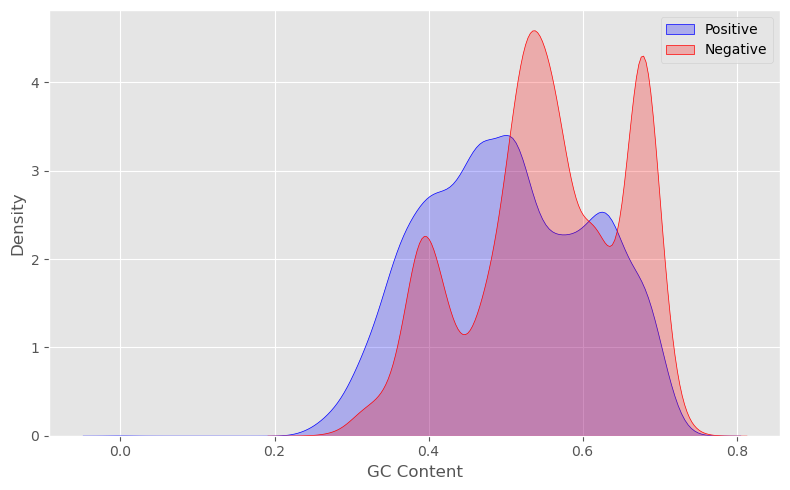

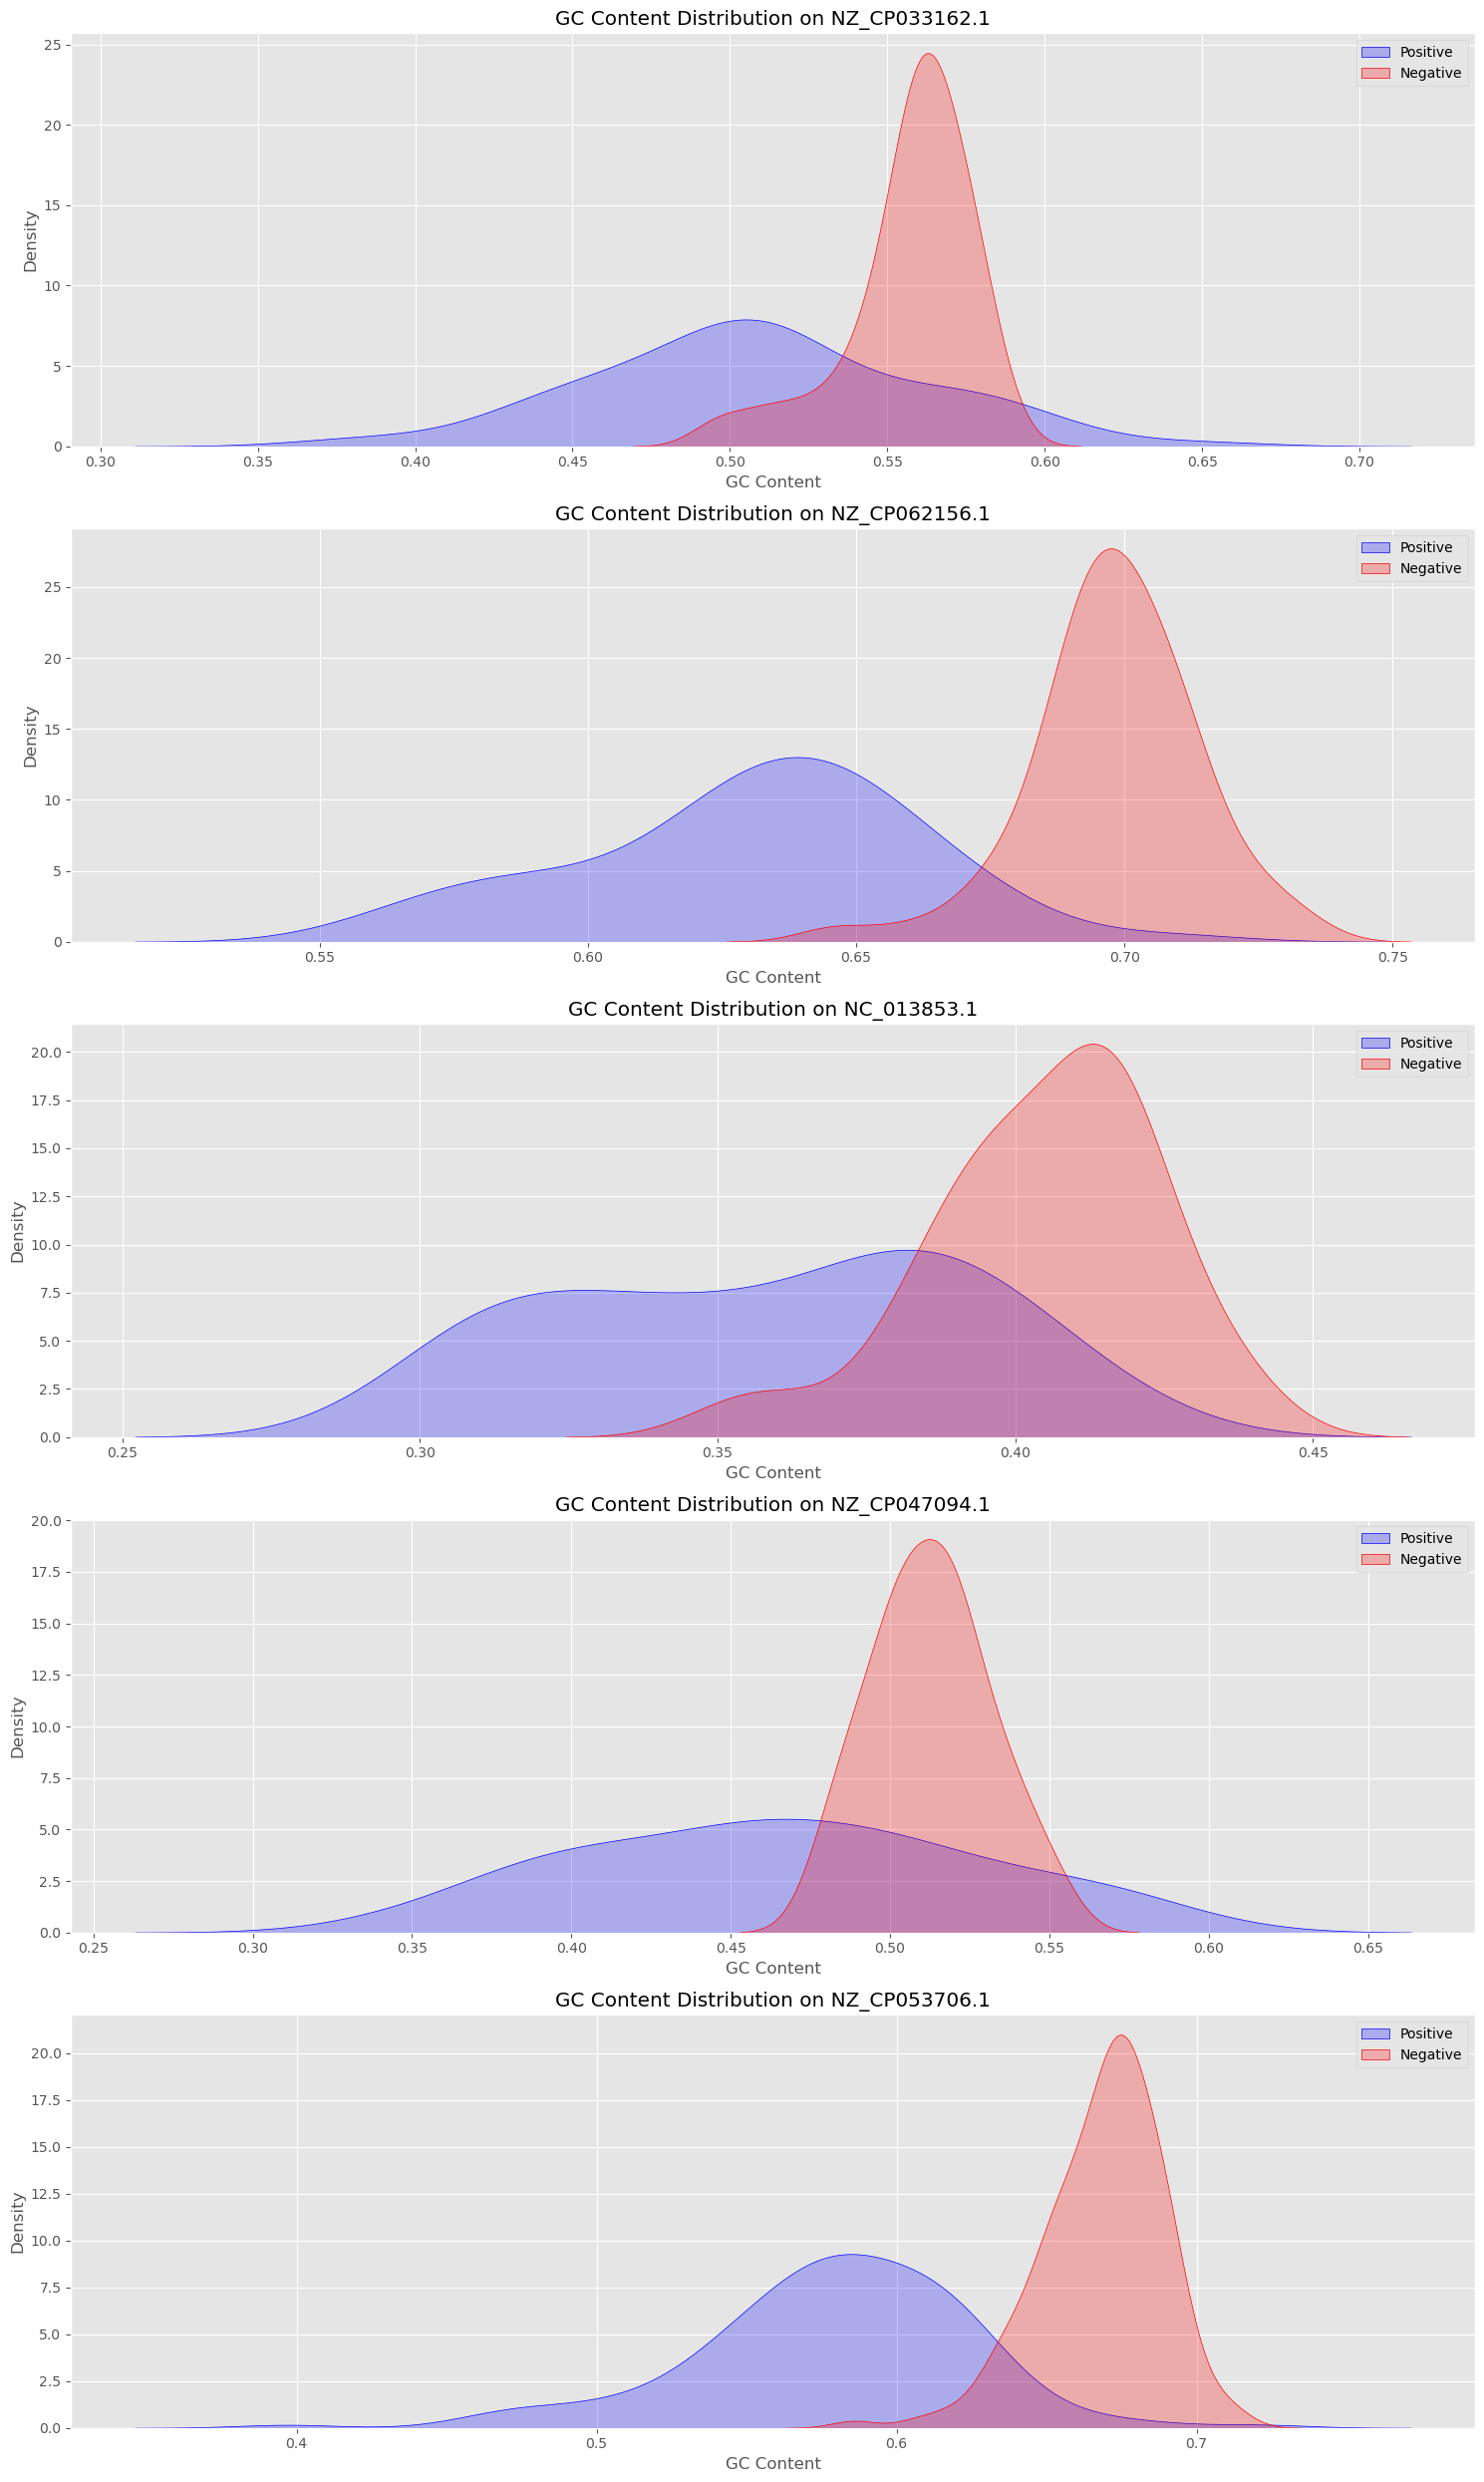

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import random 

sample_df = who_rki_sample_df
sample_df_acc = sample_df['Accession'].unique().tolist()
sample_acc = random.sample(sample_df_acc,5)

# Plot distributions
plt.figure(figsize=(8,5))
sns.kdeplot(sample_df[sample_df['Label']=='1'].gc.to_list(), label="Positive", fill=True, color="blue")
sns.kdeplot(sample_df[sample_df['Label']=='0'].gc.to_list(), label="Negative", fill=True, color="red")
plt.xlabel("GC Content")
plt.ylabel("Density")
#plt.title(f"GC Content Distribution on Chromosome {chrom}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5 * len(sample_acc)))

for i, chrom in enumerate(sample_acc, 1):
    gc_pos = sample_df[(sample_df['Accession']==chrom)&(sample_df['Label']=='1')].gc.to_list()
    gc_neg = sample_df[(sample_df['Accession']==chrom)&(sample_df['Label']=='0')].gc.to_list()
    
    plt.subplot(len(sample_acc), 1, i)
    sns.kdeplot(gc_pos, label="Positive", fill=True, color='blue')
    sns.kdeplot(gc_neg, label="Negative", fill=True, color='red')
    plt.title(f'GC Content Distribution on {chrom}')
    plt.xlabel('GC Content')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

### Write the training data pool to a FASTA file

In [ ]:
from utils.util import df_to_fasta_new

# write df to fasta file
param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/data/who_rki_training_pool.fasta"} #whether write sequences to a fasta file specified in filename

if not os.path.exists(param['filename']):
    fasta_data = who_rki_sample_df.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1).to_list()
else:
    print(f"{param['filename']} already exists!")

dataset/train_folder/data/who_rki_training_pool.fasta already exists!


In [39]:
from utils.util import df_to_fasta_new

# write df to fasta file
param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/data/training_pool_10_species_per_genus.fasta"} #whether write sequences to a fasta file specified in filename

if not os.path.exists(param['filename']):
    fasta_data = who_rki_sample_df.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1).to_list()
else:
    print(f"{param['filename']} already exists!")

100%|██████████| 23270/23270 [01:32<00:00, 250.54it/s]


### Write a FASTA file for each training case

In [113]:
# # read training data pool
from utils.util import fasta_to_df 

# training_pool_file = f"{FOLDER_TRAIN_DATA}/data/who_rki_training_pool.fasta"
# training_pool_df = fasta_to_df(training_pool_file)

training_pool_file = "dataset/mmseqs_cluster/islandviewer_sample_new_representatives.fasta" #deduplicated samples
training_pool_df = fasta_to_df(training_pool_file)

In [120]:
#Case 1: vary species and samples

with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case1.pkl", "rb") as f:
    selected_species_dict = pickle.load(f)

n_species_per_genus = selected_species_dict.keys()

for n in n_species_per_genus:
    selected_species = selected_species_dict[n].accession_version.tolist()
    pool_data_df_filtered = training_pool_df[training_pool_df['Accession'].isin(selected_species)]

    # write df to fasta file
    param = {'write_file':True,'filename':f"dataset/train_folder/deduplicated_data/deduplicated_case1_{n}.fasta"} #whether write sequences to a fasta file specified in filename
    fasta_data = pool_data_df_filtered.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1)

100%|██████████| 11380/11380 [00:46<00:00, 243.64it/s]


In [138]:
#Case 2a: balanced samples between datasets with proportional ratio to the original samples

with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case2a.pkl", "rb") as f:
    selected_species_dict = pickle.load(f)

n_species_per_genus = selected_species_dict.keys()

for n in n_species_per_genus:
    selected_species = selected_species_dict[n].accession_version.tolist()
    sampled = training_pool_df[training_pool_df['Accession'].isin(selected_species)]
    # for each accession, sample up to cap number of samples per label
    cap_dict = selected_species_dict[n][['accession_version','cap']].set_index('accession_version').to_dict()['cap']

    pool_data_df_filtered = pd.DataFrame()
    for accession in cap_dict.keys():
        n_samples = cap_dict[accession]
        #positive samples
        pos_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='1')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        #negative samples
        neg_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='0')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        pool_data_df_filtered = pd.concat([pool_data_df_filtered, pos_samples, neg_samples], axis=0)

    # write df to fasta file
    param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/deduplicated_data/deduplicated_case2a_{n}.fasta"} #whether write sequences to a fasta file specified in filename
    fasta_data = pool_data_df_filtered.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1)

100%|██████████| 2904/2904 [00:11<00:00, 247.00it/s]


In [150]:
#Case 2b: balanced samples between datasets with balanced ratio between species

with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case2b.pkl", "rb") as f:
    selected_species_dict = pickle.load(f)

n_species_per_genus = selected_species_dict.keys()

for n in n_species_per_genus:
    selected_species = selected_species_dict[n].accession_version.tolist()
    sampled = training_pool_df[training_pool_df['Accession'].isin(selected_species)]
    # for each accession, sample up to cap number of samples per label
    cap_dict = selected_species_dict[n][['accession_version','cap']].set_index('accession_version').to_dict()['cap']

    pool_data_df_filtered = pd.DataFrame()
    for accession in cap_dict.keys():
        n_samples = cap_dict[accession]
        #positive samples
        pos_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='1')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        #negative samples
        neg_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='0')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        pool_data_df_filtered = pd.concat([pool_data_df_filtered, pos_samples, neg_samples], axis=0)

    # write df to fasta file
    param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/deduplicated_data/deduplicated_case2b_{n}.fasta"} #whether write sequences to a fasta file specified in filename
    fasta_data = pool_data_df_filtered.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1).to_list()

100%|██████████| 2618/2618 [00:10<00:00, 248.16it/s]


In [157]:
#Case 3: fixed species, vary samples

with open(f"{FOLDER_TRAIN_DATA}/info/train_deduplicated_case3.pkl", "rb") as f:
    selected_species_dict = pickle.load(f)

n_species_per_genus = selected_species_dict.keys()

for n in n_species_per_genus:
    selected_species = selected_species_dict[n].accession_version.tolist()
    sampled = training_pool_df[training_pool_df['Accession'].isin(selected_species)]
    # for each accession, sample up to cap number of samples per label
    cap_dict = selected_species_dict[n][['accession_version','cap']].set_index('accession_version').to_dict()['cap']

    pool_data_df_filtered = pd.DataFrame()
    for accession in cap_dict.keys():
        n_samples = cap_dict[accession]
        #positive samples
        pos_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='1')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        #negative samples
        neg_samples = sampled[(sampled['Accession']==accession) & (sampled['Label']=='0')].apply(lambda x: x.sample(n=min(len(x),n_samples), random_state=0))
        pool_data_df_filtered = pd.concat([pool_data_df_filtered, pos_samples, neg_samples], axis=0)

    # write df to fasta file
    param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/deduplicated_data/deduplicated_case3_{n}.fasta"} #whether write sequences to a fasta file specified in filename
    fasta_data = pool_data_df_filtered.progress_apply(lambda x: df_to_fasta_new(x,
                                                                dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                query_db=False, #query sequence from database
                                                                **param), axis=1).to_list()

100%|██████████| 2618/2618 [00:10<00:00, 247.21it/s]


### Create pre-defined folds for reproducilibity

In [160]:
# cread pre-defined fold for each dataset
import json
from utils.util import read_dataset, create_fold
from sklearn.model_selection import StratifiedGroupKFold

def create_fold(X, y, groups, n_splits, n_repeats):
    """
    Create stratified folds for cross-validation with groups.
    Parameters:
    ----------
    n_splits (int): Number of splits for cross-validation.
    n_repeats (int): Number of times to repeat the cross-validation.
    X (array-like): Feature matrix.
    y (array-like): Target values.
    groups (array-like): Group labels for stratification.
    Returns:
    -------
    all_runs (list): A list containing the folds for each repeat.
    """

    all_runs = []

    for repeat in range(n_repeats):
        # Shuffle inputs (preserving correspondence)
        rng = random.getrandbits(16)
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=rng)
        folds = []

        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            # Split the data into train and test sets
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            groups_train, groups_test = groups[train_idx], groups[test_idx]
            # split X_train to train and validation sets with groups stratified and take only 1 split
            cv_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=rng)
            valid_idx, test_idx = next(cv_inner.split(X_test, y_test, groups_test))

            
            folds.append({
                "fold": fold_idx,
                "train_idx": train_idx.tolist(),
                "valid_idx": valid_idx.tolist(),
                "test_idx": test_idx.tolist()
            })

        # Store the folds for this repeat
        all_runs.append({
            "repeat": repeat,
            "folds": folds
        })

    return all_runs

train_cases = ['case1', 'case2a', 'case2b', 'case3']
n_subcases = 5

for train_case in train_cases:
    for n in range(1,n_subcases+1):
        print(f"{train_case}_{n}")

        folds_folder = f"{FOLDER_TRAIN_DATA}/deduplicated_data/pre_defined_folds/deduplicated_{train_case}_{n}_folds.json"

        if not os.path.exists(folds_folder):
            # read data
            filename = f"{FOLDER_TRAIN_DATA}/deduplicated_data/data/deduplicated_{train_case}_{n}.fasta" 
            X, y, groups, genera, species = read_dataset(filename)

            n_splits = 5
            n_repeats = 5
            all_runs = create_fold(X, y, species, n_splits=n_splits, n_repeats=n_repeats)
            
            # Save to file
            with open(folds_folder, "w") as f:
                json.dump(all_runs, f, indent=2)
        else:
            print(f"{folds_folder} already exists!")

case1_1
case1_2
case1_3
case1_4
case1_5
case2a_1
case2a_2
case2a_3
case2a_4
case2a_5
case2b_1
case2b_2
case2b_3
case2b_4
case2b_5
case3_1
case3_2
case3_3
case3_4
case3_5


## Create hold-out datasets to evaluate different training datasets on different test cases:
- test case 1 (in_species): same genera, same species, different subspecies
- test case 2 (out_species): same genera, unseen species
- test case 3 (out_genera_in_families): same families, unseen genera
- test case 4 (out_genera_out_families): unseen families, unseen genera
- test case 5 (out_phylum): unseen phylum, unseen genera
- all these cases are relative to the training data pool

### Create pool for each test case 

In [37]:
who_rki_species_ = who_rki_species['species'].unique().tolist()
who_rki_genera = who_rki_species['genus'].unique().tolist()
who_rki_families = who_rki_species['family'].unique().tolist()
who_rki_phylum = who_rki_species['phylum'].unique().tolist()

hold_out_pool = tax_id_df[~tax_id_df['accession_version'].isin(who_rki_species['accession'].unique())]

# create a pool for each test case
in_species_pool = hold_out_pool[hold_out_pool['species'].isin(who_rki_species_)]
out_species_pool = hold_out_pool[(~hold_out_pool['species'].isin(who_rki_species_)) & (hold_out_pool['genus'].isin(who_rki_genera))]
out_genera_in_families = hold_out_pool[(~hold_out_pool['genus'].isin(who_rki_genera)) & (hold_out_pool['family'].isin(who_rki_families)) & ((hold_out_pool['phylum'].isin(who_rki_phylum)))]
#out_genera_in_phylum = hold_out_pool[(~hold_out_pool['genus'].isin(who_rki_genera)) & (hold_out_pool['family'].isin(who_rki_families)) & ((hold_out_pool['phylum'].isin(who_rki_phylum)))]
out_genera_out_families = hold_out_pool[(~hold_out_pool['genus'].isin(who_rki_genera)) & (~hold_out_pool['family'].isin(who_rki_families)) & ((hold_out_pool['phylum'].isin(who_rki_phylum)))]
out_phylum_pool = hold_out_pool[(~hold_out_pool['phylum'].isin(who_rki_phylum))]

### in_species samples

In [38]:
# sample n strain per species
in_species_samples = sample_n_strains_per_species(in_species_pool, n_strains=1, random_state=0)

In [39]:
# check number of strains per species
in_species_samples['n_samples'].sum()

2976

In [40]:
fig = build_taxonomy_sankey(in_species_samples,
                            title=None,
                            levels=['phylum', 'family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

### out_species samples

In [41]:
#sample 1 strain per species for every genus
out_species_unique = sample_n_strains_per_species(out_species_pool, n_strains=1, random_state=0)
out_species_samples = sample_n_species_per_genus(out_species_unique, n_species=5, random_state=0)

In [42]:
out_species_samples['family'].nunique()

15

In [43]:
fig = build_taxonomy_sankey(out_species_samples,
                            title=None,
                            levels=['phylum', 'family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

In [44]:
#fig.write_image("figures/sankey_diagram_out_species.pdf")

### out_genera_in_families samples

In [45]:
# out_genera_in_phylum_unique_strain = sample_n_strains_per_species(out_genera_in_phylum, n_strains=1, random_state=0)
# out_genera_in_phylum_unique_species = sample_n_subtaxa_per_taxa(out_genera_in_phylum_unique_strain, taxa='genus', n_subtaxa=5, random_state=0)
# out_genera_in_phylum_samples = sample_n_subtaxa_per_taxa(out_genera_in_phylum_unique_species, taxa='family', n_subtaxa=8, random_state=0)

In [46]:
out_genera_in_families_unique_strain = sample_n_strains_per_species(out_genera_in_families, n_strains=1, random_state=0)
out_genera_in_families_unique_species = sample_n_subtaxa_per_taxa(out_genera_in_families_unique_strain, taxa='genus', n_subtaxa=5, random_state=0)
out_genera_in_families_samples = sample_n_subtaxa_per_taxa(out_genera_in_families_unique_species, taxa='family', n_subtaxa=5, random_state=0)

In [47]:
fig = build_taxonomy_sankey(out_genera_in_families_samples,
                            title=None,
                            levels=['phylum', 'family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

In [48]:
#fig.write_image("figures/sankey_diagram_out_genera_in_phylum.pdf")

### out_genera_out_families samples

In [49]:
# select families with most genera
out_genera_out_families_stats = out_genera_out_families.groupby("family")['genus'].nunique().sort_values(ascending=False).reset_index(name='n_genera')
selected_families = out_genera_out_families_stats[out_genera_out_families_stats['n_genera']>=10].family.unique().tolist()

out_genera_out_families_filtered= out_genera_out_families[out_genera_out_families['family'].isin(selected_families)]
out_genera_out_families_unique_strain = sample_n_strains_per_species(out_genera_out_families_filtered, n_strains=1, random_state=0)
out_genera_out_families_unique_species = sample_n_subtaxa_per_taxa(out_genera_out_families_unique_strain, taxa='genus', n_subtaxa=5, random_state=0)
out_genera_out_families_unique_genus = sample_n_subtaxa_per_taxa(out_genera_out_families_unique_species, taxa='family', n_subtaxa=5, random_state=0)
out_genera_out_families_samples = sample_n_subtaxa_per_taxa(out_genera_out_families_unique_genus, taxa='order', n_subtaxa=5, random_state=0)

In [50]:
fig = build_taxonomy_sankey(out_genera_out_families_samples,
                            title=None,
                            levels=['phylum','family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

In [51]:
#fig.write_image("figures/sankey_diagram_out_genera_out_families.pdf")

### out_phylum samples

In [52]:
# select top 5 phylum
out_phylum_stats = out_phylum_pool.groupby("phylum")['family'].nunique().sort_values(ascending=False).reset_index(name='n_families')
selected_phylum = out_phylum_stats[out_phylum_stats['n_families']>=9].phylum.unique().tolist()

out_phylum_filtered= out_phylum_pool[out_phylum_pool['phylum'].isin(selected_phylum)]
out_phylum_unique_strain = sample_n_strains_per_species(out_phylum_filtered, n_strains=1, random_state=0)
out_phylum_unique_species = sample_n_subtaxa_per_taxa(out_phylum_unique_strain, taxa='genus', n_subtaxa=3, random_state=0)
out_phylum_unique_genus = sample_n_subtaxa_per_taxa(out_phylum_unique_species, taxa='family', n_subtaxa=3, random_state=0)
out_phylum_samples = sample_n_subtaxa_per_taxa(out_phylum_unique_genus, taxa='order', n_subtaxa=3, random_state=0)

In [53]:
selected_phylum

['Bacteroidota',
 'Cyanobacteriota',
 'Thermodesulfobacteriota',
 'Euryarchaeota',
 'Planctomycetota',
 'Thermoproteota',
 'Chloroflexota']

In [54]:
fig = build_taxonomy_sankey(out_phylum_samples,
                            title=None,
                            levels=['phylum','family', 'genus'],
                            weight_col=None)  # or 'n_positive' if pre-aggregated
fig.show()

In [55]:
#fig.write_image("figures/sankey_diagram_out_phylum.pdf")

In [56]:
#out_phylum = sample_n_subtaxa_per_taxa(out_phylum_pool, taxa='phylum', n_subtaxa=5, random_state=0)

In [57]:
#out_phylum.n_samples.sum()

### Download the FASTA files for all selected species in each dataset

In [58]:
print("in species samples: ",in_species_samples.n_samples.sum())
print("out species samples: ",out_species_samples.n_samples.sum())
print("out genera in families samples: ",out_genera_in_families_samples.n_samples.sum())
print("out genera out families samples: ",out_genera_out_families_samples.n_samples.sum())
print("out phylum samples: ",out_phylum_samples.n_samples.sum())

in species samples:  2976
out species samples:  2809
out genera in families samples:  1637
out genera out families samples:  1839
out phylum samples:  2573


In [148]:
# # download the sequences for the selected accessions from NCBI
# from utils.util import batch_accessions, fetch_and_save_individual_fastas
# from tqdm import tqdm 

# # - test case 1 (in_species): same genera, same species, different subspecies
# # - test case 2 (out_species): same genera, unseen species
# # - test case 3 (out_genera_in_families): same families, unseen genera
# # - test case 4 (out_genera_out_families): unseen families, unseen genera

# in_species_accession = in_species_samples['accession'].unique().tolist()
# out_species_accession = out_species_samples['accession'].unique().tolist()
# out_genera_in_families_accession = out_genera_in_families_samples['accession'].unique().tolist()
# out_genera_out_families_accession = out_genera_out_families_samples['accession'].unique().tolist()

# #destination_folder = 'dataset/genomes/islandviewer4/who_rki_in_species'

# input_list = [(in_species_accession,'who_rki_in_species_test'),
#               (out_species_accession,'who_rki_out_species_test'),
#               (out_genera_in_families_accession,'who_rki_out_genus_in_families_test'),
#               (out_genera_out_families_accession,'who_rki_out_genus_out_families_test')]

# for input in tqdm(input_list):
#     accessions = input[0]
#     folder_name = input[1]

#     # Run through all batches
#     for batch in tqdm(batch_accessions(accessions, batch_size=5)):
#         fetch_and_save_individual_fastas(batch, destination_folder = f'dataset/genomes/islandviewer4/{folder_name}')

In [ ]:
## Fetching and saving FASTA files for the remaining genomes by ChatGPT
#from tqdm import tqdm
#from utils.util import batch_accessions, fetch_and_save_individual_fastas

# in_species_accession = in_species_samples['accession'].unique().tolist()

# # Run through all batches
# for batch in tqdm(batch_accessions(in_species_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=f'dataset/genomes/islandviewer4/who_rki_in_species_new')

# out_species_accession = out_species_samples['accession'].unique().tolist()
# # Run through all batches
# for batch in tqdm(batch_accessions(out_species_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=f'dataset/genomes/islandviewer4/who_rki_out_species')

# out_genera_in_families_accession = out_genera_in_families_samples['accession'].unique().tolist()
# # Run through all batches
# for batch in tqdm(batch_accessions(out_genera_in_families_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=f'dataset/genomes/islandviewer4/who_rki_out_genera_in_families')

# out_genera_out_families_accession = out_genera_out_families_samples['accession'].unique().tolist()
# # Run through all batches
# for batch in tqdm(batch_accessions(out_genera_out_families_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=f'dataset/genomes/islandviewer4/who_rki_out_genera_out_families')

# out_phylum_accession = out_phylum_samples['accession'].unique().tolist()
# # Run through all batches
# for batch in tqdm(batch_accessions(out_phylum_accession, batch_size=5)):
#     fetch_and_save_individual_fastas(batch, destination_folder=f'dataset/genomes/islandviewer4/who_rki_out_phylum')

### Negative sampling to create the test datasets

In [ ]:
# # Run the negative sampling
# who_rki_in_species_df = negatives_sampling(islandviewer_gis, genome_path = 'dataset/genomes/islandviewer4/who_rki_in_species_new')

# who_rki_out_species_df = negatives_sampling(islandviewer_gis, genome_path = 'dataset/genomes/islandviewer4/who_rki_out_species')

# who_rki_out_genera_in_families_df = negatives_sampling(islandviewer_gis, genome_path = 'dataset/genomes/islandviewer4/who_rki_out_genera_in_families')

# who_rki_out_genera_out_families_df = negatives_sampling(islandviewer_gis, genome_path = 'dataset/genomes/islandviewer4/who_rki_out_genera_out_families')

#who_rki_out_phylum_df = negatives_sampling(islandviewer_gis, genome_path = 'dataset/genomes/islandviewer4/who_rki_out_phylum')

### Write a FASTA file for each test case
-  "dataset/test_folder/who_rki_in_species.fasta"
- "dataset/test_folder/who_rki_out_species.fasta"
- "dataset/test_folder/who_rki_out_genera_in_families.fasta"
- "dataset/test_folder/who_rki_out_genera_out_families.fasta"
- "dataset/test_folder/who_rki_out_phylum.fasta"

In [ ]:
#from utils.util import df_to_fasta_new

# # write df to fasta file
# param = {'write_file':True,'filename':f"{FOLDER_TEST_DATA}/who_rki_in_species_new.fasta"} #whether write sequences to a fasta file specified in filename
# fasta_data = who_rki_in_species_df.progress_apply(lambda x: df_to_fasta_new(x,
#                                                             dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
#                                                             query_db=False, #query sequence from database
#                                                             **param), axis=1).to_list()

# # write df to fasta file
# param = {'write_file':True,'filename':f"{FOLDER_TEST_DATA}/who_rki_out_species.fasta"} #whether write sequences to a fasta file specified in filename
# fasta_data = who_rki_out_species_df.progress_apply(lambda x: df_to_fasta_new(x,
#                                                             dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
#                                                             query_db=False, #query sequence from database
#                                                             **param), axis=1).to_list()

# # write df to fasta file
# param = {'write_file':True,'filename':f"{FOLDER_TEST_DATA}/who_rki_out_genera_in_families.fasta"} #whether write sequences to a fasta file specified in filename
# fasta_data = who_rki_out_genera_in_families_df.progress_apply(lambda x: df_to_fasta_new(x,
#                                                             dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
#                                                             query_db=False, #query sequence from database
#                                                             **param), axis=1).to_list()

# # write df to fasta file
# param = {'write_file':True,'filename':f"{FOLDER_TEST_DATA}/who_rki_out_genera_out_families.fasta"} #whether write sequences to a fasta file specified in filename
# fasta_data = who_rki_out_genera_out_families_df.progress_apply(lambda x: df_to_fasta_new(x,
#                                                             dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
#                                                             query_db=False, #query sequence from database
#                                                             **param), axis=1).to_list()

# # write df to fasta file
# param = {'write_file':True,'filename':f"{FOLDER_TEST_DATA}/who_rki_out_phylum.fasta"} #whether write sequences to a fasta file specified in filename
# fasta_data = who_rki_out_phylum_df.progress_apply(lambda x: df_to_fasta_new(x,
#                                                             dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
#                                                             query_db=False, #query sequence from database
#                                                             **param), axis=1).to_list()


## Introduce data leakage to each test case

In [71]:
from sklearn.model_selection import train_test_split

# Your target percentages
fractions = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
samples = {}

who_rki_sample_df['strata'] = who_rki_sample_df['Accession'] + '_' + who_rki_sample_df['Label'] 

for f in fractions:
    # We treat 'test_size' as our desired sample size
    _, subset = train_test_split(
        who_rki_sample_df,
        test_size=f,
        stratify=who_rki_sample_df['strata'],
        random_state=42  # For reproducibility
    )
    
    # Store the result in a dictionary
    label_name = f#"{int(f*100)}%"
    samples[label_name] = subset
    
    # Quick verification of the balance
    counts = subset['strata'].value_counts(normalize=True)
    print(f"Sample {label_name}: Size={len(subset)}")#, Ratio Class 1: {counts.get(1, 0):.2f}")

Sample 0.05: Size=722
Sample 0.1: Size=1444
Sample 0.2: Size=2888
Sample 0.3: Size=4332
Sample 0.4: Size=5776
Sample 0.5: Size=7220


## Write the leakage samples to FASTA files

In [75]:
for sample in samples.items():
    print(sample[0], len(sample[1]))

    dest_file = f"{FOLDER_TEST_DATA}/data_leakage_{sample[0]}.fasta"
    if not os.path.exists(dest_file):
        # write df to fasta file
        param = {'write_file':True,'filename':dest_file} #whether write sequences to a fasta file specified in filename
        fasta_data = sample[1].progress_apply(lambda x: df_to_fasta_new(x,
                                                                    dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                    query_db=False, #query sequence from database
                                                                    **param), axis=1).to_list()

0.05 722
0.1 1444
0.2 2888
0.3 4332
0.4 5776
0.5 7220


## Prepare excel files

In [ ]:
sampled_datasets_imbalanced
sampled_datasets_balanced
sampled_datasets_balanced_uniform
sampled_datasets_vary_samples

# - total 23 genera, 111 species (5 species per genus except 1 genus)
# - case 1: vary species, vary samples
# - case 2a: vary species (1,2,3,4,5 species per genus), fixed samples to 1500 (proportional to the original ratio of the species)
# - case 2b: vary species (1,2,3,4,5 species per genus), fixed samples to 1500 (balanced ratio between species)
# - case 3: fixed species to 111 species, vary total samples (2000,3000,4000,5000)

In [ ]:
filename = "train_data_case_1"
for key in sampled_datasets_imbalanced.keys():
    dirname = f"dataset/{filename}"
    if not os.path.exists(dirname):
        os.makedirs(dirname)

    sampled_datasets_imbalanced[key].to_csv(f"{dirname}/{key}_species_per_genus_case_1.csv", index=False)

In [157]:
filename = "train_data_case_2a"

for key in sampled_datasets_balanced.keys():
    dirname = f"dataset/{filename}"

    if not os.path.exists(dirname):
        os.makedirs(dirname)

    sampled_datasets_balanced[key].to_csv(f"{dirname}/{key}_species_per_genus_case_2a.csv", index=False)

In [158]:
filename = "train_data_case_2b"

for key in sampled_datasets_balanced_uniform.keys():
    dirname = f"dataset/{filename}"

    if not os.path.exists(dirname):
        os.makedirs(dirname)

    sampled_datasets_balanced_uniform[key].to_csv(f"{dirname}/{key}_species_per_genus_case_2b.csv", index=False)

In [31]:
filename = "train_data_case_3"

for key in sampled_datasets_vary_samples.keys():
    dirname = f"dataset/{filename}"

    if not os.path.exists(dirname):
        os.makedirs(dirname)

    sampled_datasets_vary_samples[key].to_csv(f"{dirname}/{key}_samples_case_3.csv", index=False)

In [167]:
# accession ids for the test cases
test_cases = {
    'in_species': in_species_accession, 
    'out_species': out_species_accession, 
    'out_genera_in_families': out_genera_in_families_accession, 
    'out_genera_out_families':out_genera_out_families_accession
}

with open("test_case_dict.json", "w") as f:
    json.dump(test_cases, f, indent=4)


In [37]:
import os 
from utils.util import read_dataset
from Bio import SeqIO

train_folder = "dataset/train_data_temp"
new_train_folder = "dataset/train_data_new"

for file in os.listdir(train_folder):
    # read data
    filename = f"{train_folder}/{file}" 
    print(filename)

    new_records = []

    data = SeqIO.parse(filename,"fasta")
    destination_file = f"{new_train_folder}/{file}" 
    print(destination_file)

    # Writing sequences to a FASTA file
    with open(destination_file, 'w') as f:
        for record in data:
            info = record.description.split('|')
            if len(info)==5:
                description = '|'.join(info[2:])
            else:
                description = '|'.join(info)
            
            new_record = ">{}\n{}\n".format(description,record.seq)

            f.write(new_record)
        f.close()

dataset/train_data_temp/who_rki_2.fasta
dataset/train_data_new/who_rki_2.fasta
dataset/train_data_temp/who_rki_1_balanced_uniform.fasta
dataset/train_data_new/who_rki_1_balanced_uniform.fasta
dataset/train_data_temp/who_rki_5_balanced_uniform.fasta
dataset/train_data_new/who_rki_5_balanced_uniform.fasta
dataset/train_data_temp/who_rki_4.fasta
dataset/train_data_new/who_rki_4.fasta
dataset/train_data_temp/who_rki_2000_vary_samples.fasta
dataset/train_data_new/who_rki_2000_vary_samples.fasta
dataset/train_data_temp/who_rki_2_balanced_uniform.fasta
dataset/train_data_new/who_rki_2_balanced_uniform.fasta
dataset/train_data_temp/who_rki_1_balanced.fasta
dataset/train_data_new/who_rki_1_balanced.fasta
dataset/train_data_temp/who_rki_1.fasta
dataset/train_data_new/who_rki_1.fasta
dataset/train_data_temp/who_rki_3_balanced_uniform.fasta
dataset/train_data_new/who_rki_3_balanced_uniform.fasta
dataset/train_data_temp/who_rki_3_balanced.fasta
dataset/train_data_new/who_rki_3_balanced.fasta
datase

In [8]:
from utils.util import fasta_to_df, read_dataset 

train_df = fasta_to_df("dataset/train_data_new/who_rki_1.fasta")

In [10]:
X, y, groups, genera, species = read_dataset("dataset/train_data_new/who_rki_1.fasta")

In [15]:
groups

array(['NZ_CP011301.1', 'NZ_CP011301.1', 'NZ_CP011301.1', ...,
       'NZ_CP034668.1', 'NZ_CP034668.1', 'NZ_CP034668.1'], dtype='<U13')

In [145]:
import re

words = ['who_rki_1_predictions_1', 'who_rki_1_balanced_predictions_1', 'who_rki_1_balanced_uniform_predictions_1']

for word in words:
    # Look for 'a', capture everything in middle, end with 'd'
    match = re.search(r'rki_(.*)predictions', word)
    if match:
        print(match.group(1))

1_
1_balanced_
1_balanced_uniform_


In [146]:
'who_rki_1_predictions_1'.split('predictions')

['who_rki_1_', '_1']

In [152]:
def rename_files(filename):
    prefix = filename.split('predictions')[0]
    suffix = filename.split('predictions')[-1]
    digit = re.search(r'\d',prefix).group()
    digit = int(digit)%1000

    if 'balanced_uniform' in prefix:
        new_label = 'case2b'
    elif 'balanced' in prefix:
        new_label = 'case2a'
    elif 'vary' in prefix:
        new_label = 'case3'
    else:
        new_label = 'case1'

    return f"{new_label}_{digit}_predictions{suffix}"

In [154]:
rename_files("who_rki_5_balanced_predictions_6.xlsx")

'case2a_5_predictions_6.xlsx'

In [160]:
import os

folder_path = 'outputs/predictions'
folders = ['case1', 'case2a', 'case2b', 'case3']

for folder in folders:
    file_path = os.path.join(folder_path,folder)
    files = os.listdir(file_path)

    for filename in files:
        if 'who_rki' in filename:
            new_label = rename_files(filename)
        else:
            new_label = filename

        if new_label != filename:
            old_name = os.path.join(file_path, filename)
            new_name = os.path.join(file_path, new_label)
            os.rename(old_name, new_name)
            print(f"{folder}: {filename}, {new_label}")

case1: who_rki_3_predictions_6.xlsx, case1_3_predictions_6.xlsx
case1: who_rki_4_predictions_2.xlsx, case1_4_predictions_2.xlsx
case1: who_rki_5_predictions_1.xlsx, case1_5_predictions_1.xlsx
case1: who_rki_4_predictions_3.xlsx, case1_4_predictions_3.xlsx
case1: who_rki_4_predictions_4.xlsx, case1_4_predictions_4.xlsx
case1: who_rki_4_predictions_5.xlsx, case1_4_predictions_5.xlsx
case1: who_rki_5_predictions_6.xlsx, case1_5_predictions_6.xlsx
case1: who_rki_5_predictions_5.xlsx, case1_5_predictions_5.xlsx
case1: who_rki_4_predictions_6.xlsx, case1_4_predictions_6.xlsx
case1: who_rki_3_predictions_2.xlsx, case1_3_predictions_2.xlsx
case1: who_rki_3_predictions_3.xlsx, case1_3_predictions_3.xlsx
case1: who_rki_5_predictions_4.xlsx, case1_5_predictions_4.xlsx
case1: who_rki_3_predictions_4.xlsx, case1_3_predictions_4.xlsx
case1: who_rki_5_predictions_3.xlsx, case1_5_predictions_3.xlsx
case1: who_rki_5_predictions_2.xlsx, case1_5_predictions_2.xlsx
case1: who_rki_3_predictions_5.xlsx, cas

## Check the deduplicated data (islandviewer_sample_new_representatives.fasta)

In [46]:
from utils.util import fasta_to_df 

training_pool_file = "dataset/mmseqs_cluster/islandviewer_sample_new_representatives.fasta"
training_pool_df = fasta_to_df(training_pool_file)

In [ ]:
training_pool_df['species'] = training_pool_df['Description'].apply(lambda x: x.split(' ')[2])

,Accession,Sequence,Start,End,Description,Label
0,NC_010515.1,TGACCACCGCGTTTTCCGGCGACCCCGCGTCGCAACCGACCAAACA...,679623,695626,NC_010515.1|1|NC_010515.1:679623-695626 NC_010...,1
1,NC_010515.1,TGTTCGCGCAACTGGCGCGCAAACACCTCGCGCCATGTACGCAGAT...,1123145,1142041,NC_010515.1|1|NC_010515.1:1123145-1142041 NC_0...,1
2,NC_010515.1,CAGTCGACCTGCCCGACCGCCCCCTGCGCCAGCCGTCTTTTGACGC...,1381962,1423886,NC_010515.1|1|NC_010515.1:1381962-1423886 NC_0...,1
3,NC_010515.1,CAGGCCGTCCAGTCGAGAATCACCTTGCCGCTTTCGCCGGACAGCA...,1519290,1531980,NC_010515.1|1|NC_010515.1:1519290-1531980 NC_0...,1
4,NC_010515.1,TGGCAGATGAGGAATCAGCTGAGCACCCGCTGTTTTCAGAGCGCAT...,1624257,1706630,NC_010515.1|1|NC_010515.1:1624257-1706630 NC_0...,1
...,...,...,...,...,...,...
22123,NZ_CP037424.1,AAAGAATACAGGGTGATTGACCATGATAAAATCTTGCGTAGGCGCA...,1298448,1312618,NZ_CP037424.1|0|NZ_CP037424.1:1298448-1312618 ...,0
22124,NZ_CP037424.1,TCAATAGATCTACAGCGGGTAAATCACTCAAACTTACGTATTGGCC...,2390244,2413736,NZ_CP037424.1|0|NZ_CP037424.1:2390244-2413736 ...,0
22125,NZ_CP037424.1,GCACGTGACACAGGTCAAGTCGACGAATGTGCACGTACCTACACCG...,1130356,1140567,NZ_CP037424.1|0|NZ_CP037424.1:1130356-1140567 ...,0
22126,NZ_CP037424.1,ATGCCAATATGGCTAAACATGAAATATTTCATGTCTGTGACCCAGC...,1162183,1177219,NZ_CP037424.1|0|NZ_CP037424.1:1162183-1177219 ...,0


In [53]:
who_rki_species[who_rki_species['accession_version'].isin(training_pool_df.Accession.unique())].n_samples.sum() * 2

23270

In [98]:
abundant_species = ['Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus', 'Pseudomonas aeruginosa',
                    'Bordetella pertussis', 'Salmonella enterica', 'Helicobacter pylori', 'Listeria monocytogenes',
                    'Enterococcus faecalis'] # have many subspecies and positives
abundant_species_df = tax_id_df[tax_id_df['species'].isin(abundant_species)]
abundant_species_df.groupby(['phylum','species']).apply(pd.DataFrame.nlargest, n=5, columns='n_samples')['n_samples']

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_64468/4252897433.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  abundant_species_df.groupby(['phylum','species']).apply(pd.DataFrame.nlargest, n=5, columns='n_samples')['n_samples']


phylum            species                      
Bacillota         Enterococcus faecalis   14408     45
                                          14409     45
                                          14342     44
                                          23723     40
                                          139       37
                  Listeria monocytogenes  12748     16
                                          21541     15
                                          27359     15
                                          27360     15
                                          16988     14
                  Staphylococcus aureus   6256      31
                                          4408      30
                                          26763     29
                                          26778     29
                                          26538     28
Campylobacterota  Helicobacter pylori     17697      8
                                          17698      8
                 

In [96]:
# E. coli data
abundant_species = ['Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus', 'Pseudomonas aeruginosa',
                    'Bordetella pertussis', 'Salmonella enterica', 'Helicobacter pylori', 'Listeria monocytogenes',
                    'Enterococcus faecalis'] # have many subspecies and positives

abundant_species_dict = {}

for species in abundant_species:
    sampled_species_df = tax_id_df[tax_id_df['species']==species]
    top_species_ids = sampled_species_df.groupby(['phylum','species']).apply(pd.DataFrame.nlargest, n=10, columns='n_samples', include_groups=False)['accession_version'].tolist()
    abundant_species_dict[species] = top_species_ids

### Download FASTA files for each species

In [97]:
# Fetching and saving FASTA files for the remaining genomes 
from utils.util import batch_accessions, fetch_and_save_individual_fastas

for species in abundant_species:
    top_species_ids = abundant_species_dict[species]
    destination_folder = f'dataset/genomes/islandviewer4/{species}'

    # Run through all batches
    for batch in tqdm(batch_accessions(top_species_ids, batch_size=5)):
        fetch_and_save_individual_fastas(batch, destination_folder=destination_folder)

2it [00:27, 13.79s/it]
2it [00:22, 11.38s/it]
2it [00:14,  7.01s/it]
2it [00:28, 14.50s/it]
2it [00:17,  8.60s/it]
2it [00:26, 13.03s/it]
2it [00:09,  4.72s/it]
2it [00:14,  7.46s/it]
2it [00:14,  7.37s/it]


### Perform negative sampling 

In [85]:
from utils.negative_sampling import negatives_sampling

abundant_species_sample_df = pd.DataFrame()

for species in abundant_species:
    genome_path = f'dataset/genomes/islandviewer4/{species}' #who_rki_sample_10_species_per_genus

    top_species_ids = abundant_species_dict[species]
    top_species_gis = islandviewer_gis[islandviewer_gis['accession'].isin(top_species_ids)]

    # Run the negative sampling
    top_species_sample_df = negatives_sampling(top_species_gis, genome_path = genome_path)
    top_species_sample_df['species'] = species

    abundant_species_sample_df = pd.concat([abundant_species_sample_df, top_species_sample_df])


/Users/WijayaA-Dev/Documents/dataset_composition/utils/negative_sampling.py:147: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  positive_regions = pos_df.groupby('accession').apply(lambda g: list(zip(g['start'], g['end']))).to_dict()
/Users/WijayaA-Dev/Documents/dataset_composition/utils/negative_sampling.py:147: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  positive_regions = pos_df.groupby('accession').apply(lambda 

In [99]:
from utils.util import df_to_fasta_new

for species in abundant_species:
    print(species)
    species_identifier = species.lower().replace(' ','_')
    sample_species_df = abundant_species_sample_df[abundant_species_sample_df['species']==species]

    # write df to fasta file
    param = {'write_file':True,'filename':f"{FOLDER_TRAIN_DATA}/data/training_{species_identifier}.fasta"} #whether write sequences to a fasta file specified in filename

    if not os.path.exists(param['filename']):
        fasta_data = sample_species_df.progress_apply(lambda x: df_to_fasta_new(x,
                                                                    dna_only=True, #dna_only determines whether or not to process sequences with IUPAC codes
                                                                    query_db=False, #query sequence from database
                                                                    **param), axis=1).to_list()
    else:
        print(f"{param['filename']} already exists!")

Escherichia coli


100%|██████████| 1284/1284 [00:05<00:00, 230.79it/s]


Klebsiella pneumoniae


100%|██████████| 1014/1014 [00:04<00:00, 229.25it/s]


Staphylococcus aureus


...

100%|██████████| 78/78 [00:00<00:00, 210.19it/s]


Listeria monocytogenes


100%|██████████| 150/150 [00:00<00:00, 214.62it/s]


Enterococcus faecalis


100%|██████████| 422/422 [00:02<00:00, 202.91it/s]


In [91]:
species_identifier

'enterococcus_faecalis'